In [179]:
import pandas as pd
import scanpy as sc 
import commot as ct 
import numpy as np 
import anndata as ad

import matplotlib.pyplot as plt
from scipy.stats import zscore
import seaborn as sns
#import skimage

import matplotlib.pyplot as plt
import seaborn as sns


In [180]:
## read in the n
metadf = pd.read_csv('../data/RNA_meta_final.csv')
df_cn = pd.read_csv('../data/RNA_CN_zscores.csv', index_col= 0 )
metadf['cn'] = df_cn['CN']
###

## add mph labels
fullmeta = pd.read_csv('../data/milo_mphdc_srobj2.csv')      # same index/order as metadf input
index_mph = pd.read_csv('../data/milo_mphdc_ann.csv')        # has columns: index, type (p53_h/p53_l)

# start as 'Other'
fullmeta['mphmilo'] = 'Other'
fullmeta.loc[index_mph.loc[index_mph['type'] == 'p53_h', 'index'], 'mphmilo'] = 'p53_h'
fullmeta.loc[index_mph.loc[index_mph['type'] == 'p53_l', 'index'], 'mphmilo'] = 'p53_l'

metadf['mphmilo'] = fullmeta['mphmilo']

# example fov
adata = sc.read_h5ad('../data/commot_4_20v3.h5ad')

In [181]:
###general condition

metadf_sub = metadf.loc[metadf.tma_fov == '4_20', :].copy()
metadf_sub['cn'] = metadf_sub['cn'].astype(str)
metadf_sub['annV7_noNum'] = metadf_sub['annV7_noNum'].astype(str)


<Axes: >

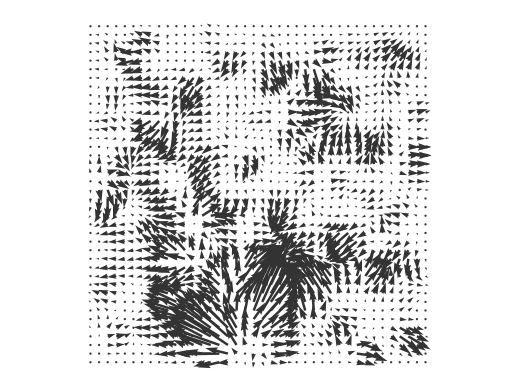

In [182]:
ct.tl.communication_direction(adata, database_name='CellChat', pathway_name = 'SPP1', k=10)
ct.pl.plot_cell_communication(adata, database_name='CellChat', pathway_name = 'SPP1', plot_method='grid',
    scale=0.00003, ndsize=0, grid_density=0.8, summary='receiver', clustering='leiden',
    normalize_v = True, normalize_v_quantile=0.995)


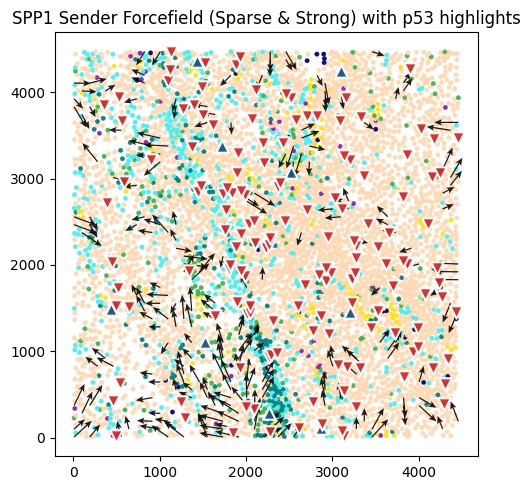

In [185]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
from matplotlib.lines import Line2D

# =========================
# 1) Cell-type palette
# =========================
pro_cc = ['#4363d8','#800000','#3cb44b','#000075','#ffe119','#46f0f0','#911eb4','#e6beff','#ffd8b1','#008080']
celltype_names = ["Ambiguous","Benign Endometrial gland","Benign Stroma","Carcinoma","Endothelial","Macrophage/DC","Myometrium","Plasma/B","Sarcoma","T"]
celltype_palette = dict(zip(celltype_names, pro_cc))
celltype_col = "annV7_noNum"

# =========================
# 2) Vectors & positions
# =========================
mode = 'sender'
pathway = 'SPP1'
vf_key = f'commot_{mode}_vf-CellChat-{pathway}'
vf = adata.obsm[vf_key]
cell_xy = adata.obsm['spatial']

celltype_series = metadf_sub[celltype_col].astype(str)
mph_series = metadf_sub['mphmilo'].astype(str)

extra_types = sorted(set(celltype_series.unique()) - set(celltype_names))
if extra_types:
    celltype_palette.update({k: tuple(c) for k, c in zip(extra_types, sns.color_palette('husl', n_colors=len(extra_types)))})

is_h = (mph_series == 'p53_h').values
is_l = (mph_series == 'p53_l').values

# =========================
# 3) Grid-averaged field (coarser + stronger)
# =========================
grid_density = 0.5      # ↓ fewer grid cells (coarser)
radius_mult  = 1.5      # ↑ larger neighborhood (smoother)
arrow_keep_q = 0.75     # keep arrows above this magnitude quantile
arrow_stride = 2        # downsample: keep every Nth arrow

nx = max(8, int(100 * grid_density)); ny = nx
xmin, xmax = cell_xy[:, 0].min(), cell_xy[:, 0].max()
ymin, ymax = cell_xy[:, 1].min(), cell_xy[:, 1].max()
x_grid = np.linspace(xmin, xmax, nx); y_grid = np.linspace(ymin, ymax, ny)
xx, yy = np.meshgrid(x_grid, y_grid)
grid_points = np.stack([xx.ravel(), yy.ravel()], axis=1)

tree = cKDTree(cell_xy)
cell_w = (xmax - xmin) / nx
cell_h = (ymax - ymin) / ny
radius = max(cell_w, cell_h) * radius_mult
idxs = tree.query_ball_point(grid_points, r=radius)

grid_vectors = np.zeros_like(grid_points)
for i, neighbors in enumerate(idxs):
    if neighbors:
        grid_vectors[i] = vf[neighbors].mean(axis=0)

# clip long vectors, preserve relative magnitudes
norm = np.linalg.norm(grid_vectors, axis=1)
qthr = np.quantile(norm, 0.95)
grid_vectors = np.where(norm[:, None] > qthr,
                        grid_vectors * (qthr / (norm[:, None] + 1e-6)),
                        grid_vectors)

# scale
scale_factor = 70
vf_scaled = grid_vectors * scale_factor

# keep nonzero & strong arrows
nz = ~np.all(vf_scaled == 0, axis=1)
grid_xy = grid_points[nz]
vf_draw = vf_scaled[nz]
mag = np.linalg.norm(vf_draw, axis=1)

if np.any(mag > 0):
    mthr = np.quantile(mag, arrow_keep_q)
    keep = mag >= mthr
else:
    keep = np.ones(len(mag), dtype=bool)

idx = np.flatnonzero(keep)[::max(1, arrow_stride)]
grid_xy = grid_xy[idx]
vf_draw = vf_draw[idx]

# =========================
# 4) Plot (lighter background, bolder arrows)
# =========================
fig, ax = plt.subplots(figsize=(5, 5))

sns.scatterplot(
    x=cell_xy[:, 0], y=cell_xy[:, 1],
    hue=celltype_series, palette=celltype_palette, s=10,
    marker='o', edgecolor=None, alpha=0.95, ax=ax, legend=False
)

ax.scatter(cell_xy[is_h, 0], cell_xy[is_h, 1], s=80, c='#165682', label='p53_h', alpha=0.95, zorder=3, marker="^", edgecolors='white', linewidths=1.5)
ax.scatter(cell_xy[is_l, 0], cell_xy[is_l, 1], s=80, c='#d62728', label='p53_l', alpha=0.95, zorder=3, marker="v", edgecolors='white', linewidths=1.5)

ax.quiver(
    grid_xy[:, 0], grid_xy[:, 1],
    vf_draw[:, 0], vf_draw[:, 1],
    width=0.003, color="#111", alpha=0.95,
    headwidth=5, headlength=6, headaxislength=5,
    scale_units='xy', scale=1, zorder=2
)

ax.set_aspect('equal')
ax.set_title(f'{pathway} {mode.capitalize()} Forcefield (Sparse & Strong) with p53 highlights')

type_handles = [Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=celltype_palette[name], markersize=5, label=name)
                for name in celltype_names if name in celltype_palette]
p53_handles = [
    Line2D([0], [0], marker='^', color='w', label='p53_h',
           markerfacecolor='#165682', markersize=8),
    Line2D([0], [0], marker='v', color='w', label='p53_l',
           markerfacecolor='#d62728', markersize=8),
]
ax.legend(handles=type_handles + p53_handles,
          loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
ax.legend_.remove()

plt.tight_layout()
plt.savefig("../plots/4_20_SPP1_celltype.png", dpi=300, bbox_inches='tight')
plt.show()


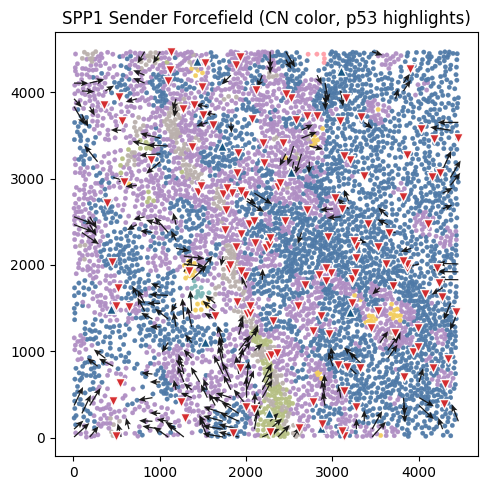

In [184]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
from matplotlib.lines import Line2D

# =========================
# 1) CN palette
# =========================
cn_levels = [str(i) for i in range(15)]  # '0' to '14'
alt15c = [
    "#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F",
    "#EDC948", "#B07AA1", "#FF9DA7", "#9C755F", "#BAB0AC",
    "#7FB8B8", "#B5BF82", "#F2CD5E", "#E78AB3", "#AF8DC3"
]
cn_palette = dict(zip(cn_levels, alt15c))

# Get CN series
cn_series = metadf_sub['cn'].astype(str)
cn_series = pd.Categorical(cn_series, categories=cn_levels, ordered=True)

# p53 highlight masks
mph_series = metadf_sub['mphmilo'].astype(str)
is_h = (mph_series == 'p53_h').values
is_l = (mph_series == 'p53_l').values

# =========================
# 2) Vector field prep
# =========================
mode = 'sender'
pathway = 'SPP1'
vf_key = f'commot_{mode}_vf-CellChat-{pathway}'
vf = adata.obsm[vf_key]
cell_xy = adata.obsm['spatial']

grid_density = 0.5
radius_mult  = 1.5
arrow_keep_q = 0.75
arrow_stride = 2

nx = max(8, int(100 * grid_density)); ny = nx
xmin, xmax = cell_xy[:, 0].min(), cell_xy[:, 0].max()
ymin, ymax = cell_xy[:, 1].min(), cell_xy[:, 1].max()
x_grid = np.linspace(xmin, xmax, nx); y_grid = np.linspace(ymin, ymax, ny)
xx, yy = np.meshgrid(x_grid, y_grid)
grid_points = np.stack([xx.ravel(), yy.ravel()], axis=1)

tree = cKDTree(cell_xy)
cell_w = (xmax - xmin) / nx
cell_h = (ymax - ymin) / ny
radius = max(cell_w, cell_h) * radius_mult
idxs = tree.query_ball_point(grid_points, r=radius)

grid_vectors = np.zeros_like(grid_points)
for i, neighbors in enumerate(idxs):
    if neighbors:
        grid_vectors[i] = vf[neighbors].mean(axis=0)

norm = np.linalg.norm(grid_vectors, axis=1)
qthr = np.quantile(norm, 0.95)
grid_vectors = np.where(norm[:, None] > qthr,
                        grid_vectors * (qthr / (norm[:, None] + 1e-6)),
                        grid_vectors)

scale_factor = 70
vf_scaled = grid_vectors * scale_factor

nz = ~np.all(vf_scaled == 0, axis=1)
grid_xy = grid_points[nz]
vf_draw = vf_scaled[nz]
mag = np.linalg.norm(vf_draw, axis=1)
mthr = np.quantile(mag, arrow_keep_q) if np.any(mag > 0) else 0
keep = (mag >= mthr)
idx = np.flatnonzero(keep)[::max(1, arrow_stride)]
grid_xy = grid_xy[idx]; vf_draw = vf_draw[idx]

# =========================
# 3) Plot
# =========================
fig, ax = plt.subplots(figsize=(5, 5))

# Base scatter: CN color scheme, size 10 (140%), no border
sns.scatterplot(
    x=cell_xy[:, 0], y=cell_xy[:, 1],
    hue=cn_series, palette=cn_palette, s=10,
    marker='o', edgecolor=None, alpha=0.95, ax=ax, legend=False
)

# p53 highlights
ax.scatter(cell_xy[is_h, 0], cell_xy[is_h, 1], s=80, c='#165682',
           label='p53_h', alpha=0.95, zorder=3, marker="^", edgecolors='white', linewidths=1.5)
ax.scatter(cell_xy[is_l, 0], cell_xy[is_l, 1], s=80, c='#d62728',
           label='p53_l', alpha=0.95, zorder=3, marker="v", edgecolors='white', linewidths=1.5)

# Quiver: 70% arrow width & head sizes
ax.quiver(
    grid_xy[:, 0], grid_xy[:, 1],
    vf_draw[:, 0], vf_draw[:, 1],
    width=0.003, color="#111", alpha=0.95,
    headwidth=5, headlength=6, headaxislength=5,
    scale_units='xy', scale=1, zorder=2
)

ax.set_aspect('equal')
ax.set_title(f'{pathway} {mode.capitalize()} Forcefield (CN color, p53 highlights)')

# Legend
cn_handles = [Line2D([0],[0], marker='o', color='w',
                     markerfacecolor=cn_palette[lev], markersize=5, label=lev)
              for lev in cn_levels]
p53_handles = [
    Line2D([0], [0], marker='^', color='w', label='p53_h',
           markerfacecolor='#165682', markersize=8),
    Line2D([0], [0], marker='v', color='w', label='p53_l',
           markerfacecolor='#d62728', markersize=8),
]
ax.legend(handles=cn_handles + p53_handles,
          loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
ax.legend_.remove()

plt.tight_layout()
plt.savefig("../plots/4_20_SPP1_CN.png", dpi=300, bbox_inches='tight')
plt.show()
